Melakukan dataset audit (identifikasi variabel, analisis tipe data, ringkasan statistik,
distribusi target, missing value analysis dan lainnya)

In [8]:
# Persiapan dan Loading Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('House Price Prediction Dataset.csv')

In [9]:
# Audit Struktur (Identifikasi Variabel & Tipe Data)

# Melihat 5 baris pertama untuk gambaran fisik data
print(df.head())

# Melihat jumlah baris dan kolom
print(f"Jumlah Baris: {df.shape[0]}, Jumlah Kolom: {df.shape[1]}")

# Melihat tipe data setiap kolom
print(df.info())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  
Jumlah Baris: 2000, Jumlah Kolom: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBui

In [10]:
# Missing Value Analysis (Analisis Data Hilang)
# Menghitung jumlah missing value per kolom
missing_data = df.isnull().sum()
print(missing_data)

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [11]:
# Audit Statistik Deskriptif
# Ringkasan statistik untuk kolom numerik
print(df.describe())

                Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  2000.00000  2000.000000   
mean   1000.500000  2786.209500     3.003500     2.55250     1.993500   
std     577.494589  1295.146799     1.424606     1.10899     0.809188   
min       1.000000   501.000000     1.000000     1.00000     1.000000   
25%     500.750000  1653.000000     2.000000     2.00000     1.000000   
50%    1000.500000  2833.000000     3.000000     3.00000     2.000000   
75%    1500.250000  3887.500000     4.000000     4.00000     3.000000   
max    2000.000000  4999.000000     5.000000     4.00000     3.000000   

         YearBuilt          Price  
count  2000.000000    2000.000000  
mean   1961.446000  537676.855000  
std      35.926695  276428.845719  
min    1900.000000   50005.000000  
25%    1930.000000  300098.000000  
50%    1961.000000  539254.000000  
75%    1993.000000  780086.000000  
max    2023.000000  999656.000000  


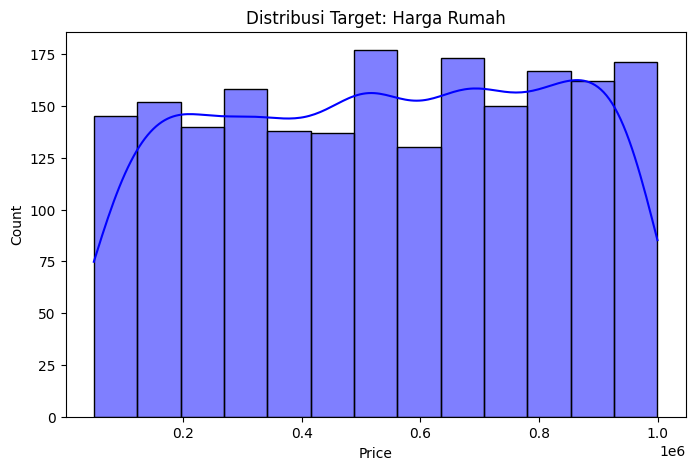

In [13]:
# Analisis Distribusi Target (Variabel 'Price')
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribusi Target: Harga Rumah')
plt.show()

In [14]:
# Audit Variabel Kategorikal
# Cek jumlah unik dan frekuensi tiap kategori
print(df['Location'].value_counts())
print(df['Condition'].value_counts())

Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64


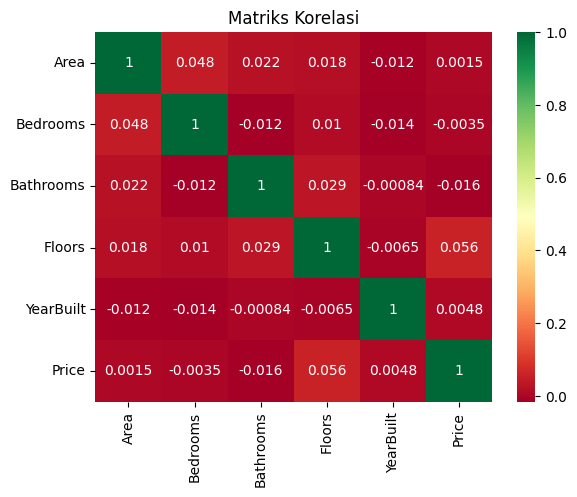

In [15]:
# Analisis Korelasi (Hubungan Antar Variabel)
# Korelasi antar kolom numerik
# Kita hapus dulu kolom Id karena tidak berguna untuk korelasi
corr_matrix = df.drop('Id', axis=1).select_dtypes(include=['number']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn')
plt.title('Matriks Korelasi')
plt.show()

## **TAHAP CLEANING**

In [16]:
# Cleaning (Pembersihan Data)

# Menghapus kolom Id
df_cleaned = df.drop('Id', axis=1)

# Menghapus baris duplikat jika ada
df_cleaned = df_cleaned.drop_duplicates()

In [20]:
# --- Kodingan Visualisasi Cleaning ---
print("Jumlah Kolom Sebelum Cleaning:", df.shape[1])
print("Jumlah Kolom Setelah Cleaning:", df_cleaned.shape[1])

# Menampilkan 5 data teratas untuk memastikan kolom 'Id' sudah hilang
df_cleaned.head()

Jumlah Kolom Sebelum Cleaning: 10
Jumlah Kolom Setelah Cleaning: 9


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


# **TAHAP SPLITTING DATA**


In [17]:
# Splitting Data (Pembagian Data)

from sklearn.model_selection import train_test_split

X = df_cleaned.drop('Price', axis=1) # Fitur
y = df_cleaned['Price'] # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

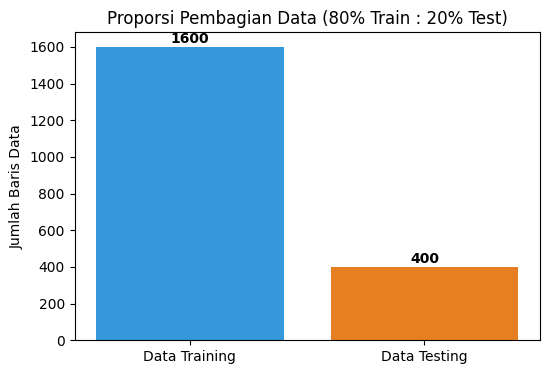

In [21]:
import matplotlib.pyplot as plt

# --- Kodingan Visualisasi Split Data ---
labels = ['Data Training', 'Data Testing']
sizes = [len(X_train), len(X_test)]

plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color=['#3498db', '#e67e22'])
plt.title('Proporsi Pembagian Data (80% Train : 20% Test)')
plt.ylabel('Jumlah Baris Data')

# Menampilkan angka di atas batang
for i, v in enumerate(sizes):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.show()

# **TAHAP ENCODING**

In [18]:
# Encoding (Mengubah Teks Menjadi Angka)

# Contoh manual mapping untuk Ordinal
mapping_kondisi = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
X_train['Condition'] = X_train['Condition'].map(mapping_kondisi)
X_test['Condition'] = X_test['Condition'].map(mapping_kondisi)

# One-Hot Encoding menggunakan pandas
X_train = pd.get_dummies(X_train, columns=['Location'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Location'], drop_first=True)

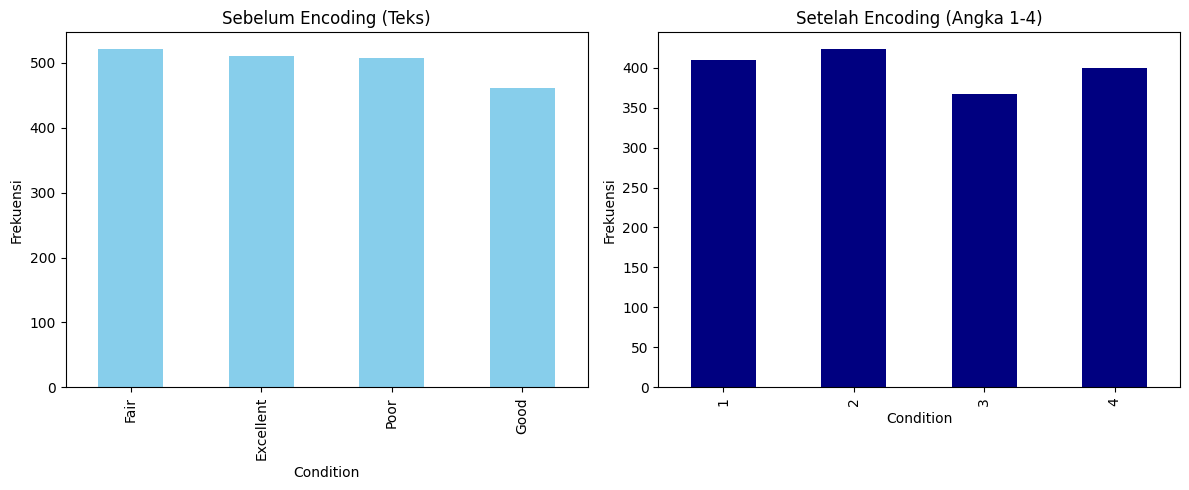

In [22]:
# --- Kodingan Visualisasi Encoding (Contoh pada Kolom Condition) ---
plt.figure(figsize=(12, 5))

# Sebelum Encoding (Data Mentah)
plt.subplot(1, 2, 1)
df['Condition'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Sebelum Encoding (Teks)')
plt.ylabel('Frekuensi')

# Sesudah Encoding (Data di X_train)
plt.subplot(1, 2, 2)
X_train['Condition'].value_counts().sort_index().plot(kind='bar', color='navy')
plt.title('Setelah Encoding (Angka 1-4)')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# **TAHAP SCALING**

In [25]:
# Scaling (Penormalan Skala)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ambil kolom numerik saja untuk di-scale
cols_to_scale = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

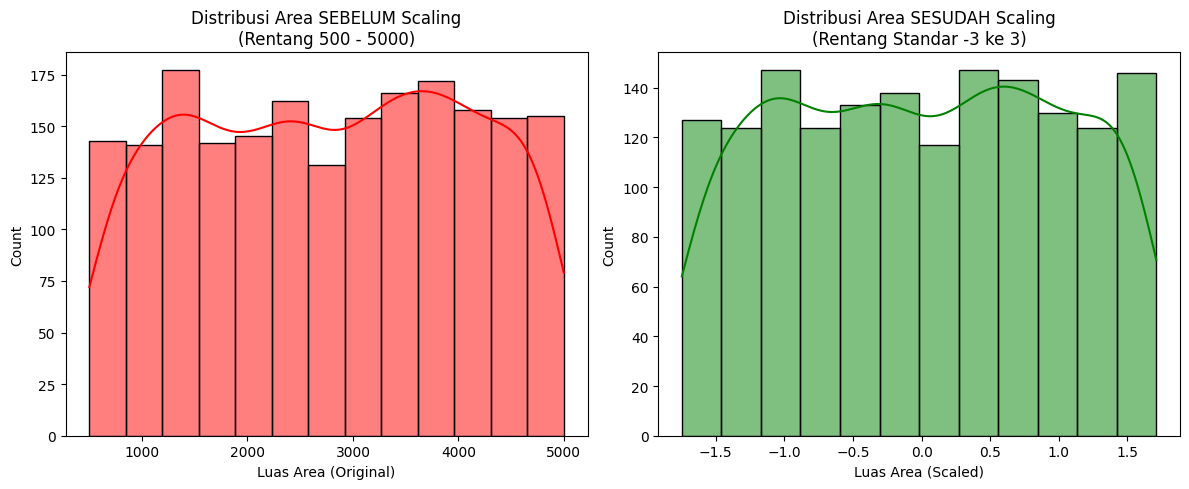

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat figure untuk perbandingan
plt.figure(figsize=(12, 5))

# 1. Visualisasi SEBELUM Scaling (Kita ambil dari data asli 'df')
plt.subplot(1, 2, 1)
sns.histplot(df['Area'], kde=True, color='red')
plt.title('Distribusi Area SEBELUM Scaling\n(Rentang 500 - 5000)')
plt.xlabel('Luas Area (Original)')

# 2. Visualisasi SESUDAH Scaling (Mengambil dari X_train yang sudah Anda proses)
plt.subplot(1, 2, 2)
sns.histplot(X_train['Area'], kde=True, color='green')
plt.title('Distribusi Area SESUDAH Scaling\n(Rentang Standar -3 ke 3)')
plt.xlabel('Luas Area (Scaled)')

plt.tight_layout()
plt.show()